In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_style("whitegrid")

print("✓ Imports successful")

✓ Imports successful


In [2]:
data_path = Path('../data/raw/Monday-WorkingHours.pcap_ISCX.csv')
print(f"Loading data from: {data_path}")

# Read the CSV
df = pd.read_csv(data_path)

print(f"✓ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")

Loading data from: ..\data\raw\Monday-WorkingHours.pcap_ISCX.csv
✓ Data loaded successfully!
Shape: (529918, 79)
Columns: 79


In [5]:
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

First 5 rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN



Column names:
0:  Destination Port
1:  Flow Duration
2:  Total Fwd Packets
3:  Total Backward Packets
4: Total Length of Fwd Packets
5:  Total Length of Bwd Packets
6:  Fwd Packet Length Max
7:  Fwd Packet Length Min
8:  Fwd Packet Length Mean
9:  Fwd Packet Length Std
10: Bwd Packet Length Max
11:  Bwd Packet Length Min
12:  Bwd Packet Length Mean
13:  Bwd Packet Length Std
14: Flow Bytes/s
15:  Flow Packets/s
16:  Flow IAT Mean
17:  Flow IAT Std
18:  Flow IAT Max
19:  Flow IAT Min
20: Fwd IAT Total
21:  Fwd IAT Mean
22:  Fwd IAT Std
23:  Fwd IAT Max
24:  Fwd IAT Min
25: Bwd IAT Total
26:  Bwd IAT Mean
27:  Bwd IAT Std
28:  Bwd IAT Max
29:  Bwd IAT Min
30: Fwd PSH Flags
31:  Bwd PSH Flags
32:  Fwd URG Flags
33:  Bwd URG Flags
34:  Fwd Header Length
35:  Bwd Header Length
36: Fwd Packets/s
37:  Bwd Packets/s
38:  Min Packet Length
39:  Max Packet Length
40:  Packet Length Mean
41:  Packet Length Std
42:  Packet Length Variance
43: FIN Flag Count
44:  SYN Flag Count
45:  RST Flag Count

Label distribution:
 Label
BENIGN    529918
Name: count, dtype: int64


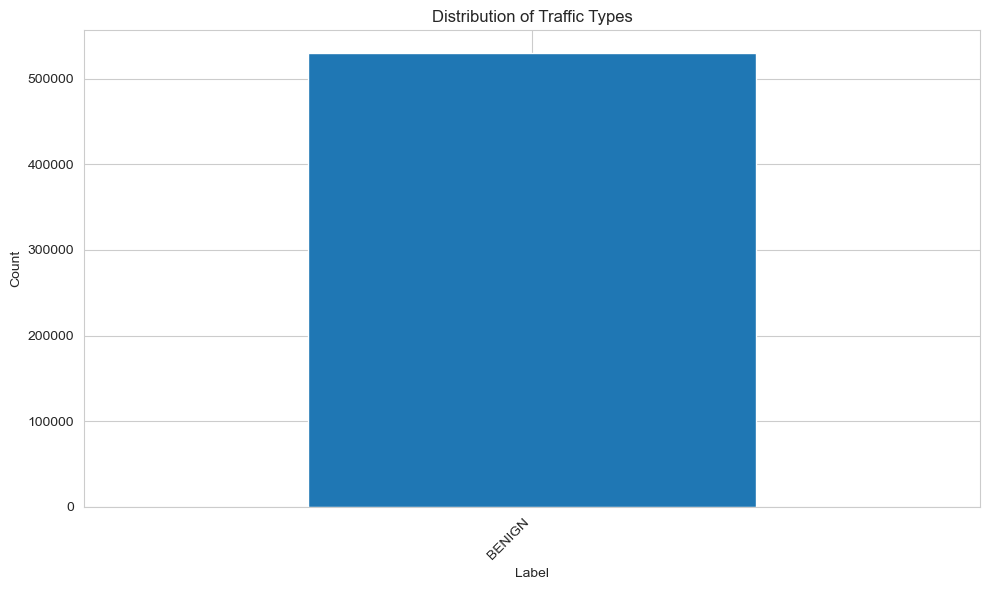

In [6]:
print("Label distribution:")
print(df[' Label'].value_counts())

# Visualize
plt.figure(figsize=(10, 6))
df[' Label'].value_counts().plot(kind='bar')
plt.title('Distribution of Traffic Types')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
print("\nData Info:")
print(df.info())

print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529918 entries, 0 to 529917
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             529918 non-null  int64  
 1    Flow Duration                529918 non-null  int64  
 2    Total Fwd Packets            529918 non-null  int64  
 3    Total Backward Packets       529918 non-null  int64  
 4   Total Length of Fwd Packets   529918 non-null  int64  
 5    Total Length of Bwd Packets  529918 non-null  int64  
 6    Fwd Packet Length Max        529918 non-null  int64  
 7    Fwd Packet Length Min        529918 non-null  int64  
 8    Fwd Packet Length Mean       529918 non-null  float64
 9    Fwd Packet Length Std        529918 non-null  float64
 10  Bwd Packet Length Max         529918 non-null  int64  
 11   Bwd Packet Length Min        529918 non-null  int64  
 12   Bwd Packet Length Mean       52

In [8]:
print("\nChecking for infinity values...")
inf_cols = []
for col in df.select_dtypes(include=[np.number]).columns:
    if np.isinf(df[col]).any():
        inf_count = np.isinf(df[col]).sum()
        inf_cols.append((col, inf_count))
        print(f"{col}: {inf_count} inf values")


Checking for infinity values...
Flow Bytes/s: 373 inf values
 Flow Packets/s: 437 inf values


In [9]:
print("\nBasic statistics for numerical columns:")
display(df.describe())


Basic statistics for numerical columns:


c:\Users\DELL\anaconda3\envs\adversarial311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\DELL\anaconda3\envs\adversarial311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,529918.000000,5.299180e+05,529918.000000,529918.000000,5.299180e+05,5.299180e+05,529918.000000,529918.000000,529918.000000,529918.000000,...,529918.000000,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05,5.299180e+05
mean,10644.367112,1.038927e+07,10.390315,11.517105,5.324195e+02,1.789841e+04,190.897188,20.277279,50.744078,57.452269,...,7.412509,-3.614576e+03,6.843482e+04,4.321930e+04,1.453907e+05,4.380369e+04,3.463918e+06,2.024408e+05,3.620657e+06,3.274066e+06
std,21390.213475,2.875195e+07,892.412791,1173.318788,6.228642e+03,2.675470e+06,448.833754,36.275793,91.964713,146.518081,...,851.762351,5.526328e+05,5.872322e+05,3.971455e+05,1.028606e+06,4.993677e+05,1.297057e+07,2.170149e+06,1.340649e+07,1.273216e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.760000e+02,2.000000,1.000000,1.800000e+01,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,3.130300e+04,2.000000,2.000000,6.800000e+01,1.440000e+02,40.000000,6.000000,38.000000,0.000000,...,1.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,3.557448e+05,4.000000,3.000000,1.870000e+02,3.920000e+02,83.000000,40.000000,53.000000,26.162951,...,3.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65535.000000,1.200000e+08,219759.000000,291922.000000,1.323378e+06,6.554530e+08,23360.000000,2293.000000,4638.923469,7125.596846,...,213557.000000,1.260000e+02,1.016597e+08,6.434950e+07,1.016597e+08,1.016597e+08,1.199997e+08,7.514502e+07,1.199997e+08,1.199997e+08


In [10]:
findings = {
    'total_samples': len(df),
    'num_features': len(df.columns) - 1,  # Exclude label
    'num_classes': df[' Label'].nunique(),
    'class_distribution': df[' Label'].value_counts().to_dict(),
    'missing_values': df.isnull().sum().sum(),
    'inf_values': len(inf_cols)
}

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
for key, value in findings.items():
    print(f"{key}: {value}")

print("\n✓ Day 1 exploration complete!")
print("Next step: Data cleaning and preprocessing")


SUMMARY
total_samples: 529918
num_features: 78
num_classes: 1
class_distribution: {'BENIGN': 529918}
missing_values: 64
inf_values: 2

✓ Day 1 exploration complete!
Next step: Data cleaning and preprocessing
